# FASE 2: Entrenamiento del modelo de riesgo por ubicación

**Proyecto:** Sistema de alerta temprana de accidentes de tránsito en Cuenca mediante una Red Neuronal Artificial.

## Objetivo

Entrenar una red neuronal de **regresión** para estimar un porcentaje de riesgo histórico relativo entre 0 y 100, usando las variables preparadas en la Fase 1.

El notebook carga el archivo:

`datos_fase1_riesgo_ubicacion.pkl`

generado por la Fase 1.


## 1. Importación de librerías

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Configuración de reproducibilidad

Se fija una semilla para que los resultados sean más consistentes entre ejecuciones.


In [2]:
SEMILLA = 42

np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

print("Semilla configurada:", SEMILLA)

Semilla configurada: 42


## 3. Carga de los datos generados en la Fase 1

El archivo `.pkl` debe estar en la misma carpeta que este notebook.


In [3]:
RUTA_DATOS = "datos_fase1_riesgo_ubicacion.pkl"

with open(RUTA_DATOS, "rb") as archivo:
    datos = pickle.load(archivo)

print("Tipo de objeto cargado:", type(datos))
print("Claves disponibles:")
print(datos.keys())

Tipo de objeto cargado: <class 'dict'>
Claves disponibles:
dict_keys(['X_train_transformado', 'X_test_transformado', 'Y_train', 'Y_test', 'preprocesador', 'columnas_entrada', 'variables_numericas', 'variables_categoricas', 'max_accidentes'])


## 4. Recuperación de variables

Se recuperan los conjuntos de entrenamiento y prueba, el preprocesador y las variables utilizadas.


In [4]:
X_train_transformado = datos["X_train_transformado"]
X_test_transformado = datos["X_test_transformado"]

Y_train = np.asarray(datos["Y_train"], dtype=np.float32)
Y_test = np.asarray(datos["Y_test"], dtype=np.float32)

preprocesador = datos["preprocesador"]
columnas_entrada = datos["columnas_entrada"]
variables_numericas = datos["variables_numericas"]
variables_categoricas = datos["variables_categoricas"]
max_accidentes = datos["max_accidentes"]

print("X_train_transformado:", X_train_transformado.shape)
print("X_test_transformado:", X_test_transformado.shape)
print("Y_train:", Y_train.shape)
print("Y_test:", Y_test.shape)
print("Máximo histórico usado en Fase 1:", max_accidentes)

print("\nVariables de entrada:")
print(columnas_entrada)

X_train_transformado: (1291, 35)
X_test_transformado: (323, 35)
Y_train: (1291,)
Y_test: (323,)
Máximo histórico usado en Fase 1: 11

Variables de entrada:
['MES', 'DIA_SIN', 'DIA_COS', 'HORA_SIN', 'HORA_COS', 'RANGO_HORARIO', 'PARROQUIA', 'ZONA', 'FERIADO']


In [5]:
# Asignar mayor importancia a los valores de riesgo alto

sample_weight = np.ones_like(Y_train, dtype=float)

sample_weight[Y_train >= 0.70] = 4.0
sample_weight[
    (Y_train >= 0.40) &
    (Y_train < 0.70)
] = 2.0

print("Pesos únicos:", np.unique(sample_weight))

Pesos únicos: [4.]


## 5. Revisión de la variable objetivo

La salida representa el porcentaje de riesgo histórico relativo.

Se revisa la distribución antes del entrenamiento.


In [6]:
print("Estadísticas de Y_train:")
print(pd.Series(Y_train).describe())

print("\nEstadísticas de Y_test:")
print(pd.Series(Y_test).describe())

Estadísticas de Y_train:
count    1291.000000
mean       29.806454
std        22.855991
min         9.090000
25%         9.090000
50%        18.180000
75%        45.450001
max       100.000000
dtype: float64

Estadísticas de Y_test:
count    323.000000
mean      30.198515
std       21.378006
min        9.090000
25%        9.090000
50%       27.270000
75%       45.450001
max      100.000000
dtype: float64


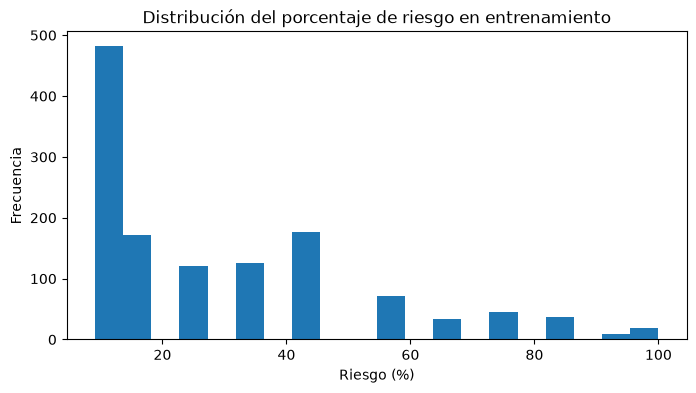

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(Y_train, bins=20)
plt.title("Distribución del porcentaje de riesgo en entrenamiento")
plt.xlabel("Riesgo (%)")
plt.ylabel("Frecuencia")
plt.show()

## 6. Número de variables de entrada

El número de entradas corresponde al total de columnas después del preprocesamiento.


In [8]:
n_entradas = X_train_transformado.shape[1]

print("Número de entradas transformadas:", n_entradas)

Número de entradas transformadas: 35


## 7. Creación de la red neuronal

Se utiliza una arquitectura moderada para reducir el riesgo de sobreajuste.

La salida tiene una sola neurona con activación `sigmoid`. Luego se multiplica por 100 para obtener un porcentaje entre 0 y 100.


In [9]:
modelo = Sequential([
    Input(shape=(n_entradas,)),

    Dense(64, activation="relu"),
    Dropout(0.30),

    Dense(32, activation="relu"),
    Dropout(0.20),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")
])

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Escalado de la variable objetivo

Como la salida del modelo está entre 0 y 1, se divide el porcentaje entre 100 durante el entrenamiento.


In [10]:
Y_train_escalado = Y_train / 100.0
Y_test_escalado = Y_test / 100.0

print("Mínimo Y_train escalado:", Y_train_escalado.min())
print("Máximo Y_train escalado:", Y_train_escalado.max())

Mínimo Y_train escalado: 0.090900004
Máximo Y_train escalado: 1.0


## 9. Compilación del modelo

Se usa:

- `Adam` como optimizador.
- `mean_squared_error` como función de pérdida.
- `mean_absolute_error` como métrica adicional.


In [11]:
modelo.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

## 10. Configuración de callbacks

- `EarlyStopping`: detiene el entrenamiento si el error de validación deja de mejorar.
- `ReduceLROnPlateau`: reduce la tasa de aprendizaje cuando el modelo se estanca.


In [12]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reducir_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

## 11. Entrenamiento del modelo

Se utiliza el 20 % del conjunto de entrenamiento para validación.


In [13]:
historial = modelo.fit(
    X_train_transformado,
    Y_train_escalado,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    sample_weight=sample_weight,
    callbacks=[early_stopping, reducir_lr],
    verbose=1
)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2374 - mean_absolute_error: 0.2046 - val_loss: 0.2019 - val_mean_absolute_error: 0.1742 - learning_rate: 0.0010
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1640 - mean_absolute_error: 0.1629 - val_loss: 0.1563 - val_mean_absolute_error: 0.1474 - learning_rate: 0.0010
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1408 - mean_absolute_error: 0.1440 - val_loss: 0.1305 - val_mean_absolute_error: 0.1296 - learning_rate: 0.0010
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1234 - mean_absolute_error: 0.1309 - val_loss: 0.1201 - val_mean_absolute_error: 0.1215 - learning_rate: 0.0010
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1146 - mean_absolute_error: 0.1231 - val_loss: 0.1164 - val_mean_absolute_error: 0.1193 - learning_rate: 0.0010
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1118 - mean_absolute_error: 0.1222 - val_loss: 0.1131 - val_mean_absolute_

## 12. Curva de pérdida

Permite comparar el error de entrenamiento con el error de validación.


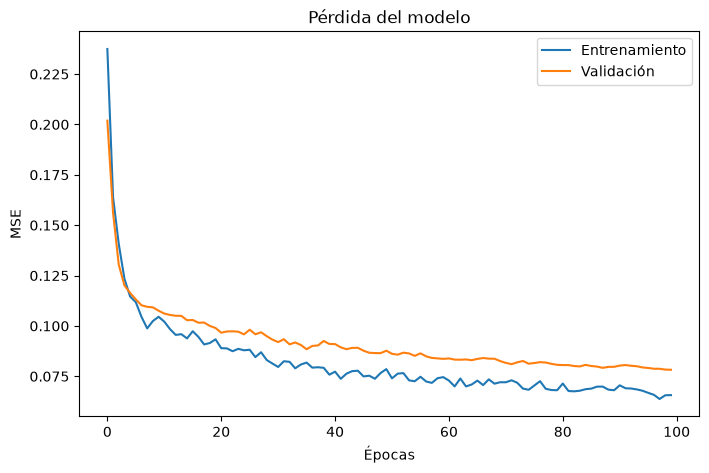

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(historial.history["loss"], label="Entrenamiento")
plt.plot(historial.history["val_loss"], label="Validación")
plt.title("Pérdida del modelo")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.show()

## 13. Curva de MAE

El MAE representa el error absoluto promedio durante el entrenamiento.


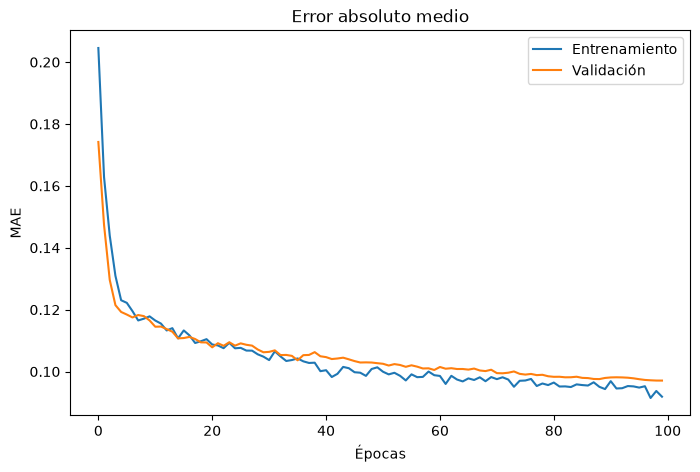

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(historial.history["mean_absolute_error"], label="Entrenamiento")
plt.plot(historial.history["val_mean_absolute_error"], label="Validación")
plt.title("Error absoluto medio")
plt.xlabel("Épocas")
plt.ylabel("MAE")
plt.legend()
plt.show()

## 14. Predicciones sobre el conjunto de prueba

Las predicciones se convierten nuevamente al rango de 0 a 100.


In [16]:
predicciones_escaladas = modelo.predict(
    X_test_transformado,
    verbose=0
).reshape(-1)

predicciones_porcentaje = np.clip(
    predicciones_escaladas * 100,
    0,
    100
)

print("Primeras predicciones:")
print(predicciones_porcentaje[:10])

print("\nPrimeros valores reales:")
print(Y_test[:10])

Primeras predicciones:
[42.11811   12.279675  46.686012  21.485207   6.5568066 67.94682
 39.374237  51.927544  11.941938  29.356539 ]

Primeros valores reales:
[63.64  9.09 54.55 27.27  9.09 54.55 45.45 63.64  9.09 27.27]


## 15. Evaluación del modelo

Se calculan:

- MAE: error absoluto medio.
- MSE: error cuadrático medio.
- RMSE: raíz del error cuadrático medio.
- R²: proporción de variabilidad explicada por el modelo.


In [17]:
mae = mean_absolute_error(Y_test, predicciones_porcentaje)
mse = mean_squared_error(Y_test, predicciones_porcentaje)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, predicciones_porcentaje)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  9.8421
MSE:  176.4961
RMSE: 13.2852
R²:   0.6126


## 16. Comparación entre valores reales y predichos

Esta gráfica permite observar qué tan cerca están las predicciones de los valores reales.


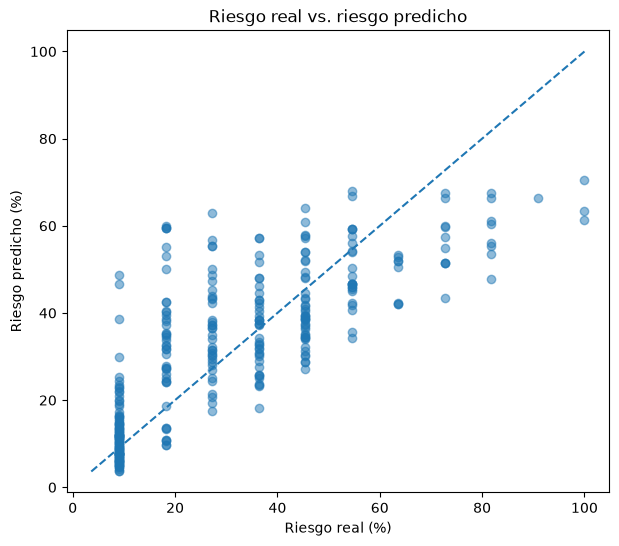

In [18]:
plt.figure(figsize=(7, 6))
plt.scatter(Y_test, predicciones_porcentaje, alpha=0.5)

limite_min = min(Y_test.min(), predicciones_porcentaje.min())
limite_max = max(Y_test.max(), predicciones_porcentaje.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--"
)

plt.title("Riesgo real vs. riesgo predicho")
plt.xlabel("Riesgo real (%)")
plt.ylabel("Riesgo predicho (%)")
plt.show()

## 17. Tabla de resultados

Se muestran ejemplos del conjunto de prueba.


In [19]:
resultados = pd.DataFrame({
    "RIESGO_REAL": Y_test,
    "RIESGO_PREDICHO": predicciones_porcentaje
})

resultados["ERROR_ABSOLUTO"] = (
    resultados["RIESGO_REAL"]
    - resultados["RIESGO_PREDICHO"]
).abs()

resultados.head(20)

,RIESGO_REAL,RIESGO_PREDICHO,ERROR_ABSOLUTO
0,63.639999,42.118111,21.521889
1,9.090000,12.279675,3.189674
2,54.549999,46.686012,7.863987
3,27.270000,21.485207,5.784794
4,9.090000,6.556807,2.533194
5,54.549999,67.946823,13.396824
6,45.450001,39.374237,6.075764
7,63.639999,51.927544,11.712456
8,9.090000,11.941938,2.851938
9,27.270000,29.356539,2.086538


## 18. Conversión del porcentaje a nivel de riesgo

Se aplican los umbrales definidos en el proyecto:

- Bajo: menor o igual a 39 %.
- Medio: entre 40 % y 69 %.
- Alto: mayor o igual a 70 %.


In [20]:
print(resultados["RIESGO_PREDICHO"].describe())

count    323.000000
mean      31.421724
std       17.878361
min        3.623458
25%       13.410062
50%       32.122173
75%       45.169510
max       70.475037
Name: RIESGO_PREDICHO, dtype: float64


In [21]:
limite_medio = resultados["RIESGO_PREDICHO"].quantile(0.60)
limite_alto = resultados["RIESGO_PREDICHO"].quantile(0.85)

print(limite_medio)
print(limite_alto)

def clasificar_nivel_riesgo(porcentaje):

    if porcentaje >= limite_alto:
        return "ALTO"

    elif porcentaje >= limite_medio:
        return "MEDIO"

    else:
        return "BAJO"

resultados["NIVEL_REAL"] = (
    resultados["RIESGO_REAL"]
    .apply(clasificar_nivel_riesgo)
)

resultados["NIVEL_PREDICHO"] = (
    resultados["RIESGO_PREDICHO"]
    .apply(clasificar_nivel_riesgo)
)

resultados.head(20)

37.52608413696289
52.05261993408203


,RIESGO_REAL,RIESGO_PREDICHO,ERROR_ABSOLUTO,NIVEL_REAL,NIVEL_PREDICHO
0,63.639999,42.118111,21.521889,ALTO,MEDIO
1,9.090000,12.279675,3.189674,BAJO,BAJO
2,54.549999,46.686012,7.863987,ALTO,MEDIO
3,27.270000,21.485207,5.784794,BAJO,BAJO
4,9.090000,6.556807,2.533194,BAJO,BAJO
5,54.549999,67.946823,13.396824,ALTO,ALTO
6,45.450001,39.374237,6.075764,MEDIO,MEDIO
7,63.639999,51.927544,11.712456,ALTO,MEDIO
8,9.090000,11.941938,2.851938,BAJO,BAJO
9,27.270000,29.356539,2.086538,BAJO,BAJO


## 19. Exactitud de los niveles de riesgo

Aunque el modelo es de regresión, también se puede evaluar cuántas veces coincide la clasificación final.


In [22]:
exactitud_nivel = (
    resultados["NIVEL_REAL"]
    == resultados["NIVEL_PREDICHO"]
).mean()

print(f"Exactitud del nivel de riesgo: {exactitud_nivel:.4f}")

Exactitud del nivel de riesgo: 0.6842


## 20. Matriz de confusión de los niveles

Esta matriz evalúa la clasificación derivada del porcentaje predicho.


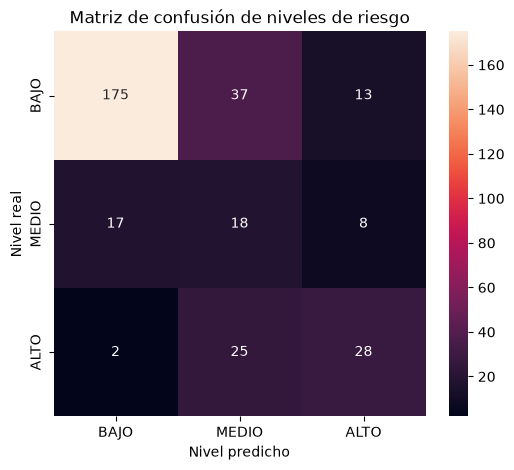

              precision    recall  f1-score   support

        BAJO       0.90      0.78      0.84       225
       MEDIO       0.23      0.42      0.29        43
        ALTO       0.57      0.51      0.54        55

    accuracy                           0.68       323
   macro avg       0.57      0.57      0.56       323
weighted avg       0.76      0.68      0.71       323



In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

orden_clases = ["BAJO", "MEDIO", "ALTO"]

matriz = confusion_matrix(
    resultados["NIVEL_REAL"],
    resultados["NIVEL_PREDICHO"],
    labels=orden_clases
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    xticklabels=orden_clases,
    yticklabels=orden_clases
)

plt.title("Matriz de confusión de niveles de riesgo")
plt.xlabel("Nivel predicho")
plt.ylabel("Nivel real")
plt.show()

print(classification_report(
    resultados["NIVEL_REAL"],
    resultados["NIVEL_PREDICHO"],
    labels=orden_clases,
    zero_division=0
))

## 21. Guardado del modelo

Se guarda el modelo entrenado para usarlo en la Fase 3 o en una aplicación web.


In [24]:
modelo.save("modelo_riesgo_ubicacion_cuenca.keras")

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


## 22. Guardado de métricas e historial

Se guardan las métricas y el historial para documentar el entrenamiento.


In [25]:
metricas_modelo = {
    "MAE": float(mae),
    "MSE": float(mse),
    "RMSE": float(rmse),
    "R2": float(r2),
    "EXACTITUD_NIVEL": float(exactitud_nivel)
}

with open("metricas_modelo_riesgo.pkl", "wb") as archivo:
    pickle.dump(metricas_modelo, archivo)

with open("historial_modelo_riesgo.pkl", "wb") as archivo:
    pickle.dump(historial.history, archivo)

print("Métricas e historial guardados correctamente.")
print(metricas_modelo)

Métricas e historial guardados correctamente.
{'MAE': 9.842070579528809, 'MSE': 176.49612426757812, 'RMSE': 13.285184389671757, 'R2': 0.6126108765602112, 'EXACTITUD_NIVEL': 0.6842105263157895}


## 23. Guardado de resultados de prueba

Este archivo puede utilizarse en el informe o para analizar errores del modelo.


In [26]:
resultados.to_csv(
    "resultados_prueba_modelo_riesgo.csv",
    index=False,
    encoding="utf-8-sig",
    sep=";",
    decimal=","
)

print("Resultados guardados correctamente.")

Resultados guardados correctamente.


## 24. Resumen de la Fase 2

En esta fase se realizó:

1. Carga de los datos preparados en la Fase 1.
2. Creación de una red neuronal de regresión.
3. Entrenamiento con EarlyStopping y reducción de la tasa de aprendizaje.
4. Predicción del porcentaje de riesgo.
5. Evaluación mediante MAE, MSE, RMSE y R².
6. Conversión del porcentaje a nivel bajo, medio o alto.
7. Evaluación de los niveles mediante matriz de confusión.
8. Guardado del modelo, métricas, historial y resultados.

La Fase 3 cargará el modelo y recibirá nuevos datos de fecha, hora, parroquia, zona y feriado para generar una predicción.
